In [219]:
import numpy as np

In [220]:
def data_generator(n_samples=10000, fr = 0.1, seed=37):
    np.random.seed(seed)
    nneg = int(fr*n_samples)
    npos = n_samples - nneg
    
    ypred_pos = np.round(np.clip(np.random.normal(0.75, 0.2, npos), 0, 1), 3)
    ypred_neg = np.round(np.clip(np.random.normal(0.25, 0.2, nneg), 0, 1), 3)
    
    output = np.vstack((
        np.c_[ypred_pos, np.ones(npos)],
        np.c_[ypred_neg, np.zeros(nneg)]
    ))
    np.random.shuffle(output)
    return output

data = data_generator()

In [221]:
sorted_arr = data[np.lexsort((data[:, 1], -data[:, 0]))]

In [222]:
sorted_arr

array([[1., 1.],
       [1., 1.],
       [1., 1.],
       ...,
       [0., 0.],
       [0., 1.],
       [0., 1.]])

In [223]:
thresholds_indices = np.where(np.diff(sorted_arr[:, 0]))[0]
thresholds_indices

array([ 968,  978,  982,  989,  997, 1005, 1014, 1019, 1031, 1039, 1048,
       1052, 1063, 1067, 1077, 1086, 1097, 1110, 1120, 1129, 1142, 1149,
       1157, 1165, 1178, 1183, 1196, 1199, 1207, 1215, 1226, 1237, 1251,
       1263, 1271, 1277, 1288, 1302, 1312, 1323, 1332, 1342, 1355, 1371,
       1379, 1382, 1391, 1403, 1412, 1421, 1425, 1439, 1448, 1458, 1462,
       1471, 1479, 1487, 1499, 1513, 1525, 1534, 1542, 1559, 1569, 1579,
       1594, 1604, 1618, 1627, 1635, 1648, 1657, 1669, 1691, 1709, 1723,
       1738, 1752, 1762, 1774, 1785, 1795, 1812, 1829, 1838, 1852, 1864,
       1880, 1888, 1903, 1915, 1931, 1946, 1958, 1967, 1979, 1993, 2007,
       2019, 2031, 2043, 2058, 2072, 2084, 2098, 2108, 2117, 2125, 2136,
       2156, 2174, 2193, 2210, 2219, 2238, 2251, 2261, 2275, 2293, 2308,
       2325, 2339, 2353, 2364, 2376, 2395, 2410, 2427, 2443, 2457, 2474,
       2502, 2514, 2529, 2541, 2552, 2565, 2578, 2595, 2604, 2620, 2633,
       2649, 2662, 2674, 2696, 2711, 2723, 2743, 27

In [224]:
thresholds_indices = np.r_[thresholds_indices, len(data) - 1]
thresholds_indices

array([ 968,  978,  982,  989,  997, 1005, 1014, 1019, 1031, 1039, 1048,
       1052, 1063, 1067, 1077, 1086, 1097, 1110, 1120, 1129, 1142, 1149,
       1157, 1165, 1178, 1183, 1196, 1199, 1207, 1215, 1226, 1237, 1251,
       1263, 1271, 1277, 1288, 1302, 1312, 1323, 1332, 1342, 1355, 1371,
       1379, 1382, 1391, 1403, 1412, 1421, 1425, 1439, 1448, 1458, 1462,
       1471, 1479, 1487, 1499, 1513, 1525, 1534, 1542, 1559, 1569, 1579,
       1594, 1604, 1618, 1627, 1635, 1648, 1657, 1669, 1691, 1709, 1723,
       1738, 1752, 1762, 1774, 1785, 1795, 1812, 1829, 1838, 1852, 1864,
       1880, 1888, 1903, 1915, 1931, 1946, 1958, 1967, 1979, 1993, 2007,
       2019, 2031, 2043, 2058, 2072, 2084, 2098, 2108, 2117, 2125, 2136,
       2156, 2174, 2193, 2210, 2219, 2238, 2251, 2261, 2275, 2293, 2308,
       2325, 2339, 2353, 2364, 2376, 2395, 2410, 2427, 2443, 2457, 2474,
       2502, 2514, 2529, 2541, 2552, 2565, 2578, 2595, 2604, 2620, 2633,
       2649, 2662, 2674, 2696, 2711, 2723, 2743, 27

In [225]:
tps = np.cumsum(sorted_arr[:, 1])[thresholds_indices]
fps = np.cumsum((1 - sorted_arr[:, 1]))[thresholds_indices]

In [226]:
tpr = tps / tps[-1]
fpr = fps / fps[-1]

Text(0, 0.5, 'TPR')

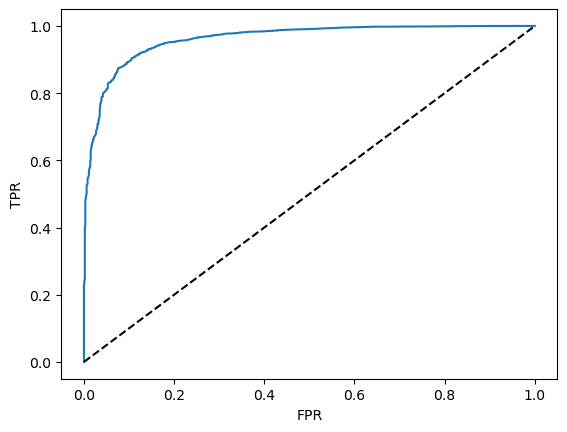

In [232]:
import matplotlib.pyplot as plt
plt.plot(np.r_[0, fpr], np.r_[0, tpr])
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')